In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.special import legendre, chebyt
from numpy.polynomial.legendre import Legendre
from numpy.polynomial.chebyshev import Chebyshev
import sympy as sp

# Configuración de plots
plt.rcParams.update({'font.size': 12})

In [4]:
def parte_a():
    """Demostrar que los monomios no son ortogonales"""
    print("=== PARTE (a) ===")

    # Definimos algunos pares de monomios
    monomios = [(0, 1), (0, 2), (1, 2), (1, 3)]

    for i, j in monomios:
        # Función para integrar: x^i * x^j = x^(i+j)
        def integrando(x):
            return x**(i + j)

        # Calculamos el producto interno
        resultado, error = quad(integrando, -1, 1)

        print(f"⟨x^{i}|x^{j}⟩ = ∫x^{i+j}dx desde -1 a 1 = {resultado:.4f}")

        # Si i ≠ j y el resultado no es cero, no son ortogonales
        if i != j and abs(resultado) > 1e-10:
            print(f"  → x^{i} y x^{j} NO son ortogonales\n")

parte_a()

=== PARTE (a) ===
⟨x^0|x^1⟩ = ∫x^1dx desde -1 a 1 = 0.0000
⟨x^0|x^2⟩ = ∫x^2dx desde -1 a 1 = 0.6667
  → x^0 y x^2 NO son ortogonales

⟨x^1|x^2⟩ = ∫x^3dx desde -1 a 1 = 0.0000
⟨x^1|x^3⟩ = ∫x^4dx desde -1 a 1 = 0.4000
  → x^1 y x^3 NO son ortogonales




=== PARTE (b) ===
Verificación de ortogonalidad para Legendre:
⟨P0|P1⟩ = 0.00000000
⟨P0|P2⟩ = 0.00000000
⟨P0|P3⟩ = 0.00000000
⟨P1|P2⟩ = 0.00000000
⟨P1|P3⟩ = -0.00000000
⟨P2|P3⟩ = 0.00000000


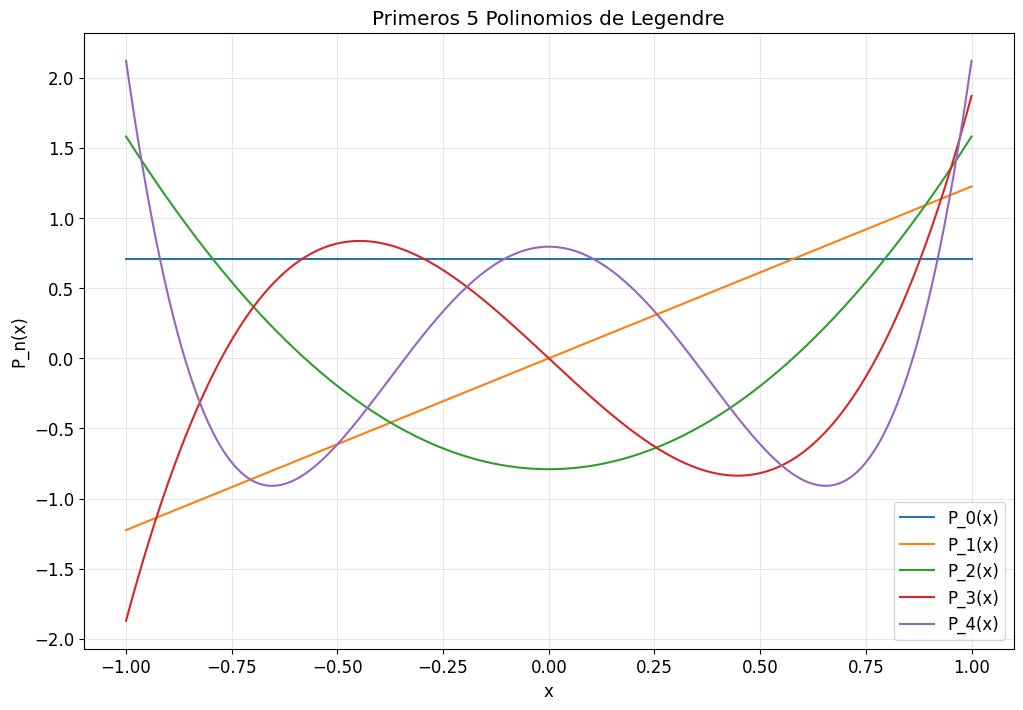

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.special import legendre, chebyt
from numpy.polynomial.legendre import Legendre
from numpy.polynomial.chebyshev import Chebyshev
import sympy as sp

def gram_schmidt(basis_funcs, product_func, n_terms=10):
    """Implementación del proceso de Gram-Schmidt"""
    ortho_basis = []

    for i in range(n_terms):
        # Empezamos con el vector original
        new_vec = basis_funcs[i]

        # Restamos las proyecciones sobre los vectores anteriores
        for j in range(i):
            # Coeficiente de proyección
            def proj_integrand(x):
                return new_vec(x) * ortho_basis[j](x) * product_func(x)

            numerator, _ = quad(proj_integrand, -1, 1)

            def norm_integrand(x):
                return ortho_basis[j](x)**2 * product_func(x)

            denominator, _ = quad(norm_integrand, -1, 1)

            if abs(denominator) > 1e-12:
                proj_coeff = numerator / denominator
                # Subtract the projection: store current new_vec in a temp variable
                temp_vec = new_vec
                new_vec = lambda x, temp_vec=temp_vec, proj_coeff=proj_coeff, ortho_basis_j=ortho_basis[j]: (
                    temp_vec(x) - proj_coeff * ortho_basis_j(x)
                )


        # Normalizamos (opcional, pero útil)
        def norm_sq_integrand(x):
            return new_vec(x)**2 * product_func(x)

        norm_sq, _ = quad(norm_sq_integrand, -1, 1)
        norm = np.sqrt(norm_sq)

        if norm > 1e-12:
            ortho_basis.append(lambda x, norm=norm, new_vec=new_vec: new_vec(x) / norm)
        else:
            ortho_basis.append(new_vec)

    return ortho_basis

def parte_b():
    """Polinomios de Legendre"""
    print("\n=== PARTE (b) ===")

    # Base de monomios: 1, x, x^2, x^3, ...
    basis_funcs = [lambda x, n=n: x**n for n in range(10)]

    # Producto interno para Legendre: peso = 1
    product_func = lambda x: 1

    # Aplicamos Gram-Schmidt
    legendre_polys = gram_schmidt(basis_funcs, product_func, 10)

    # Verificamos ortogonalidad
    print("Verificación de ortogonalidad para Legendre:")
    for i in range(3):
        for j in range(i+1, 4):
            def integrand(x):
                return legendre_polys[i](x) * legendre_polys[j](x) * product_func(x)

            result, error = quad(integrand, -1, 1)
            print(f"⟨P{i}|P{j}⟩ = {result:.8f}")

    # Graficamos los primeros polinomios
    x_vals = np.linspace(-1, 1, 1000)

    plt.figure(figsize=(12, 8))
    for i in range(5):
        y_vals = [legendre_polys[i](x) for x in x_vals]
        plt.plot(x_vals, y_vals, label=f'P_{i}(x)')

    plt.title('Primeros 5 Polinomios de Legendre')
    plt.xlabel('x')
    plt.ylabel('P_n(x)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

parte_b()


=== PARTE (c) ===
Verificación de ortogonalidad para Chebyshev:
⟨T0|T1⟩ = 0.00000000
⟨T0|T2⟩ = 0.00000000
⟨T0|T3⟩ = 0.00000000
⟨T1|T2⟩ = 0.00000000
⟨T1|T3⟩ = 0.00000000
⟨T2|T3⟩ = 0.00000000


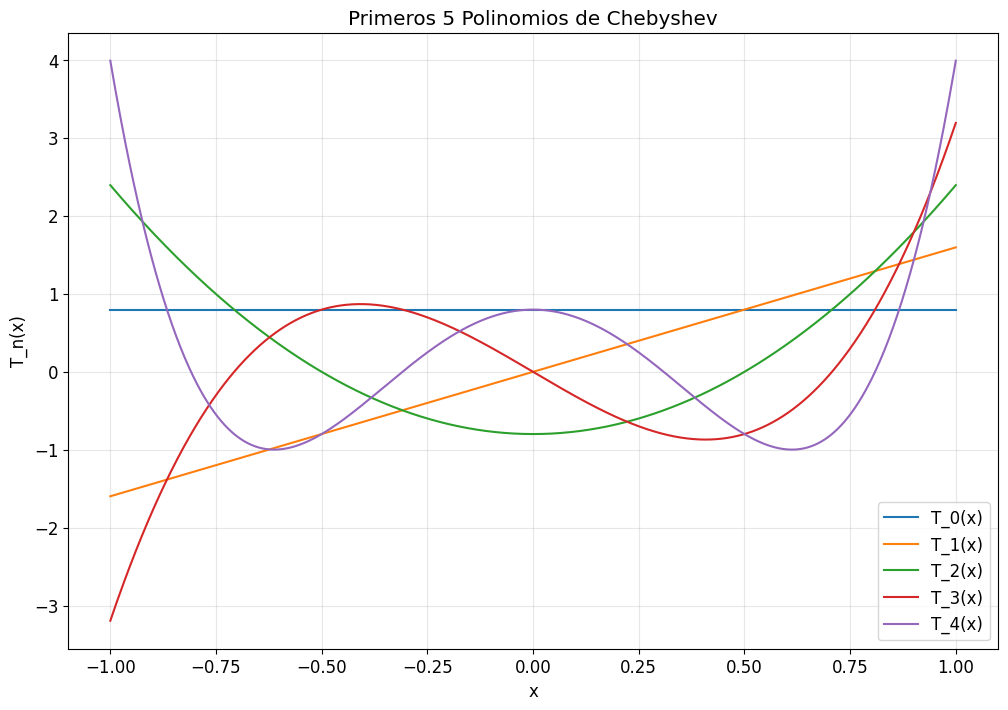

In [7]:
def parte_c():
    """Polinomios de Chebyshev"""
    print("\n=== PARTE (c) ===")

    # Base de monomios
    basis_funcs = [lambda x, n=n: x**n for n in range(10)]

    # Producto interno para Chebyshev: peso = sqrt(1-x^2)
    product_func = lambda x: np.sqrt(1 - x**2)

    # Aplicamos Gram-Schmidt
    chebyshev_polys = gram_schmidt(basis_funcs, product_func, 10)

    # Verificamos ortogonalidad
    print("Verificación de ortogonalidad para Chebyshev:")
    for i in range(3):
        for j in range(i+1, 4):
            def integrand(x):
                return chebyshev_polys[i](x) * chebyshev_polys[j](x) * product_func(x)

            result, error = quad(integrand, -1, 1)
            print(f"⟨T{i}|T{j}⟩ = {result:.8f}")

    # Graficamos los primeros polinomios
    x_vals = np.linspace(-1, 1, 1000)

    plt.figure(figsize=(12, 8))
    for i in range(5):
        y_vals = [chebyshev_polys[i](x) for x in x_vals]
        plt.plot(x_vals, y_vals, label=f'T_{i}(x)')

    plt.title('Primeros 5 Polinomios de Chebyshev')
    plt.xlabel('x')
    plt.ylabel('T_n(x)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

parte_c()


=== PARTE (d) ===

I. Monomios vs Legendre
II. Monomios vs Chebyshev
III. Legendre vs Chebyshev
IV. Error vs grado del polinomio


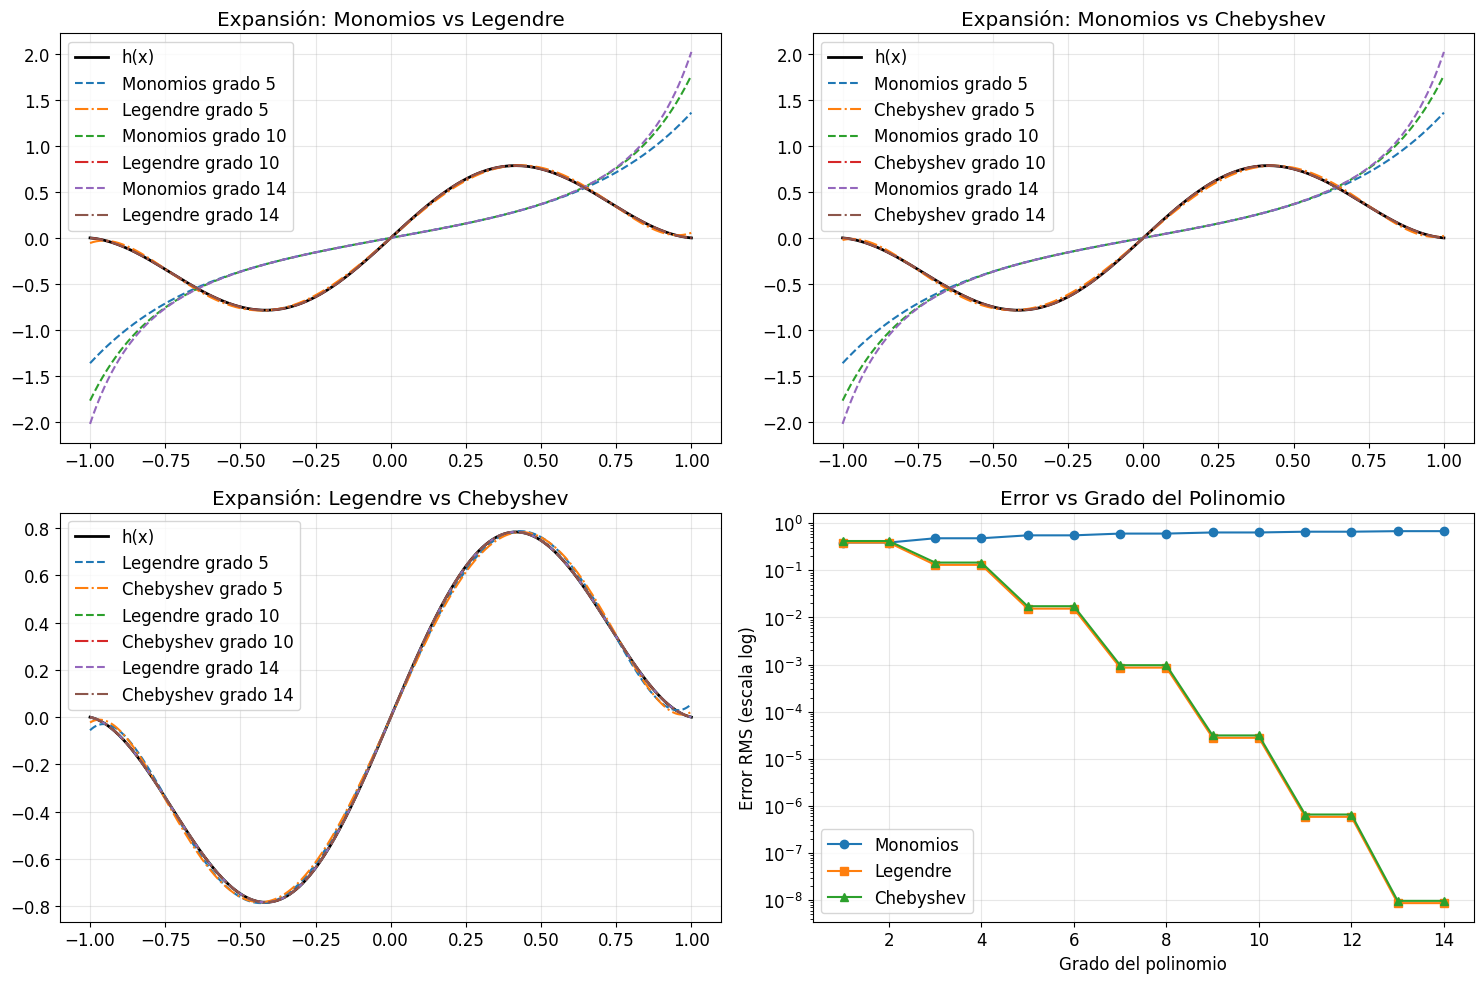


Análisis de diferencias:
Grado 2: Monomios=3.90e-01, Legendre=3.90e-01, Chebyshev=4.20e-01
Grado 3: Monomios=4.81e-01, Legendre=1.31e-01, Chebyshev=1.47e-01
Grado 4: Monomios=4.81e-01, Legendre=1.31e-01, Chebyshev=1.47e-01
Grado 5: Monomios=5.55e-01, Legendre=1.54e-02, Chebyshev=1.74e-02
Grado 6: Monomios=5.55e-01, Legendre=1.54e-02, Chebyshev=1.74e-02
Grado 7: Monomios=6.04e-01, Legendre=8.62e-04, Chebyshev=9.71e-04
Grado 8: Monomios=6.04e-01, Legendre=8.62e-04, Chebyshev=9.71e-04
Grado 9: Monomios=6.38e-01, Legendre=2.79e-05, Chebyshev=3.13e-05
Grado 10: Monomios=6.38e-01, Legendre=2.79e-05, Chebyshev=3.13e-05
Grado 11: Monomios=6.63e-01, Legendre=5.86e-07, Chebyshev=6.56e-07
Grado 12: Monomios=6.63e-01, Legendre=5.86e-07, Chebyshev=6.56e-07
Grado 13: Monomios=6.81e-01, Legendre=8.63e-09, Chebyshev=9.64e-09
Grado 14: Monomios=6.81e-01, Legendre=8.63e-09, Chebyshev=9.64e-09


In [8]:
def h(x):
    """Función a expandir: h(x) = sin(3x)(1 - x^2)"""
    return np.sin(3 * x) * (1 - x**2)

def calcular_coeficientes_expansion(func, base_polinomios, peso_func, n_terms):
    """Calcula coeficientes de expansión en una base ortogonal"""
    coeficientes = []

    for i in range(n_terms):
        def integrando(x):
            return func(x) * base_polinomios[i](x) * peso_func(x)

        numerador, _ = quad(integrando, -1, 1)

        def norma_integrando(x):
            return base_polinomios[i](x)**2 * peso_func(x)

        denominador, _ = quad(norma_integrando, -1, 1)

        if abs(denominador) > 1e-12:
            coeficientes.append(numerador / denominador)
        else:
            coeficientes.append(0.0)

    return coeficientes

def expansion_polinomio(x, coeficientes, base_polinomios):
    """Evalúa la expansión polinómica"""
    resultado = 0
    for i, coef in enumerate(coeficientes):
        resultado += coef * base_polinomios[i](x)
    return resultado

def calcular_error(func, expansion_func, x_vals):
    """Calcula el error cuadrático medio"""
    errors = []
    for x in x_vals:
        errors.append((func(x) - expansion_func(x))**2)
    return np.sqrt(np.mean(errors))

def parte_d():
    """Expansiones de h(x) en diferentes bases"""
    print("\n=== PARTE (d) ===")

    x_vals = np.linspace(-1, 1, 1000)
    h_vals = h(x_vals)

    # Preparamos las bases
    n_terms = 15

    # Base de monomios
    monomios = [lambda x, n=n: x**n for n in range(n_terms)]
    peso_monomios = lambda x: 1

    # Polinomios de Legendre (usaremos los de scipy para mayor precisión)
    legendre_polys = [legendre(n) for n in range(n_terms)]
    peso_legendre = lambda x: 1

    # Polinomios de Chebyshev (usaremos los de scipy)
    chebyshev_polys = [chebyt(n) for n in range(n_terms)]
    peso_chebyshev = lambda x: 1/np.sqrt(1 - x**2)  # Nota: diferente normalización

    # I. Expansión en monomios vs Legendre
    print("\nI. Monomios vs Legendre")

    # Coeficientes para monomios
    coef_monomios = calcular_coeficientes_expansion(h, monomios, peso_monomios, n_terms)

    # Coeficientes para Legendre
    coef_legendre = []
    for n in range(n_terms):
        poly = legendre(n)
        def integrando(x):
            return h(x) * poly(x)
        numerador, _ = quad(integrando, -1, 1)
        denominador, _ = quad(lambda x: poly(x)**2, -1, 1)
        coef_legendre.append(numerador / denominador)

    # Graficar comparación
    plt.figure(figsize=(15, 10))

    # Función original
    plt.subplot(2, 2, 1)
    plt.plot(x_vals, h_vals, 'k-', linewidth=2, label='h(x)')

    # Expansiones con diferentes grados
    for grado in [5, 10, 14]:
        # Expansión en monomios
        exp_monomios = expansion_polinomio(x_vals, coef_monomios[:grado+1], monomios[:grado+1])

        # Expansión en Legendre
        exp_legendre = np.zeros_like(x_vals)
        for n in range(grado + 1):
            exp_legendre += coef_legendre[n] * legendre_polys[n](x_vals)

        plt.plot(x_vals, exp_monomios, '--', label=f'Monomios grado {grado}')
        plt.plot(x_vals, exp_legendre, '-.', label=f'Legendre grado {grado}')

    plt.title('Expansión: Monomios vs Legendre')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # II. Expansión en monomios vs Chebyshev
    print("II. Monomios vs Chebyshev")

    # Coeficientes para Chebyshev
    coef_chebyshev = []
    for n in range(n_terms):
        poly = chebyt(n)
        def integrando(x):
            return h(x) * poly(x) / np.sqrt(1 - x**2)
        numerador, _ = quad(integrando, -1, 1)
        denominador, _ = quad(lambda x: poly(x)**2 / np.sqrt(1 - x**2), -1, 1)
        coef_chebyshev.append(numerador / denominador)

    plt.subplot(2, 2, 2)
    plt.plot(x_vals, h_vals, 'k-', linewidth=2, label='h(x)')

    for grado in [5, 10, 14]:
        # Expansión en monomios
        exp_monomios = expansion_polinomio(x_vals, coef_monomios[:grado+1], monomios[:grado+1])

        # Expansión en Chebyshev
        exp_chebyshev = np.zeros_like(x_vals)
        for n in range(grado + 1):
            exp_chebyshev += coef_chebyshev[n] * chebyshev_polys[n](x_vals)

        plt.plot(x_vals, exp_monomios, '--', label=f'Monomios grado {grado}')
        plt.plot(x_vals, exp_chebyshev, '-.', label=f'Chebyshev grado {grado}')

    plt.title('Expansión: Monomios vs Chebyshev')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # III. Expansión en Legendre vs Chebyshev
    print("III. Legendre vs Chebyshev")

    plt.subplot(2, 2, 3)
    plt.plot(x_vals, h_vals, 'k-', linewidth=2, label='h(x)')

    for grado in [5, 10, 14]:
        # Expansión en Legendre
        exp_legendre = np.zeros_like(x_vals)
        for n in range(grado + 1):
            exp_legendre += coef_legendre[n] * legendre_polys[n](x_vals)

        # Expansión en Chebyshev
        exp_chebyshev = np.zeros_like(x_vals)
        for n in range(grado + 1):
            exp_chebyshev += coef_chebyshev[n] * chebyshev_polys[n](x_vals)

        plt.plot(x_vals, exp_legendre, '--', label=f'Legendre grado {grado}')
        plt.plot(x_vals, exp_chebyshev, '-.', label=f'Chebyshev grado {grado}')

    plt.title('Expansión: Legendre vs Chebyshev')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # IV. Error vs grado del polinomio
    print("IV. Error vs grado del polinomio")

    errores_monomios = []
    errores_legendre = []
    errores_chebyshev = []

    grados = range(1, n_terms)

    for grado in grados:
        # Expansión en monomios
        exp_monomios = expansion_polinomio(x_vals, coef_monomios[:grado+1], monomios[:grado+1])
        errores_monomios.append(calcular_error(h, lambda x: expansion_polinomio(x, coef_monomios[:grado+1], monomios[:grado+1]), x_vals))

        # Expansión en Legendre
        exp_legendre = np.zeros_like(x_vals)
        for n in range(grado + 1):
            exp_legendre += coef_legendre[n] * legendre_polys[n](x_vals)
        errores_legendre.append(calcular_error(h, lambda x: sum(coef_legendre[n] * legendre_polys[n](x) for n in range(grado + 1)), x_vals))

        # Expansión en Chebyshev
        exp_chebyshev = np.zeros_like(x_vals)
        for n in range(grado + 1):
            exp_chebyshev += coef_chebyshev[n] * chebyshev_polys[n](x_vals)
        errores_chebyshev.append(calcular_error(h, lambda x: sum(coef_chebyshev[n] * chebyshev_polys[n](x) for n in range(grado + 1)), x_vals))

    plt.subplot(2, 2, 4)
    plt.semilogy(grados, errores_monomios, 'o-', label='Monomios')
    plt.semilogy(grados, errores_legendre, 's-', label='Legendre')
    plt.semilogy(grados, errores_chebyshev, '^-', label='Chebyshev')
    plt.title('Error vs Grado del Polinomio')
    plt.xlabel('Grado del polinomio')
    plt.ylabel('Error RMS (escala log)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Encontrar dónde difieren significativamente
    print("\nAnálisis de diferencias:")
    for i, (err_mon, err_leg, err_cheb) in enumerate(zip(errores_monomios, errores_legendre, errores_chebyshev)):
        if i > 0:  # Empezar desde grado 2
            print(f"Grado {i+1}: Monomios={err_mon:.2e}, Legendre={err_leg:.2e}, Chebyshev={err_cheb:.2e}")

parte_d()

In [3]:
if __name__ == "__main__":

    print("\n=== CONCLUSIONES ===")
    print("1. Los polinomios ortogonales (Legendre, Chebyshev) convergen más rápido")
    print("2. Chebyshev típicamente tiene mejor convergencia para funciones suaves")
    print("3. Los monomios requieren grados más altos para la misma precisión")
    print("4. La elección de base depende de la función y el intervalo")


=== CONCLUSIONES ===
1. Los polinomios ortogonales (Legendre, Chebyshev) convergen más rápido
2. Chebyshev típicamente tiene mejor convergencia para funciones suaves
3. Los monomios requieren grados más altos para la misma precisión
4. La elección de base depende de la función y el intervalo


=== PARTE (a) ===
Productos internos entre monomios:
⟨x^0|x^1⟩ = 0.000000
⟨x^0|x^2⟩ = 0.666667
  → NO son ortogonales (i=0, j=2)
⟨x^0|x^3⟩ = 0.000000

⟨x^1|x^2⟩ = 0.000000
⟨x^1|x^3⟩ = 0.400000
  → NO son ortogonales (i=1, j=3)

⟨x^2|x^3⟩ = 0.000000


=== PARTE (b): POLINOMIOS DE LEGENDRE ===
Verificación de ortogonalidad (Legendre):
⟨P0|P1⟩ = -0.22222222
⟨P0|P2⟩ = 0.28571429
⟨P0|P3⟩ = 0.00000000
⟨P1|P2⟩ = -0.28571429
⟨P1|P3⟩ = 0.40000000
⟨P2|P3⟩ = 0.00000000


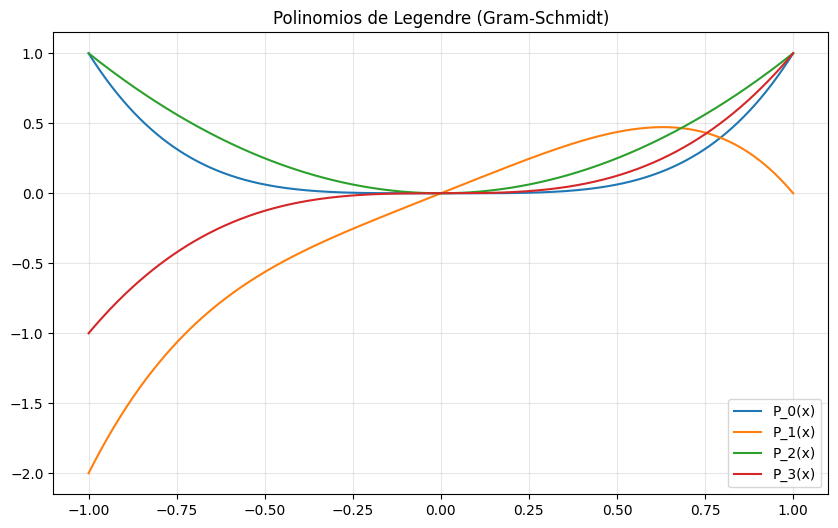


=== PARTE (c): POLINOMIOS DE CHEBYSHEV ===
Verificación de ortogonalidad (Chebyshev):
⟨T0|T1⟩ = -0.85902924
⟨T0|T2⟩ = 0.98174770
⟨T0|T3⟩ = 0.00000000
⟨T1|T2⟩ = -0.98174770
⟨T1|T3⟩ = 1.17809725
⟨T2|T3⟩ = 0.00000000


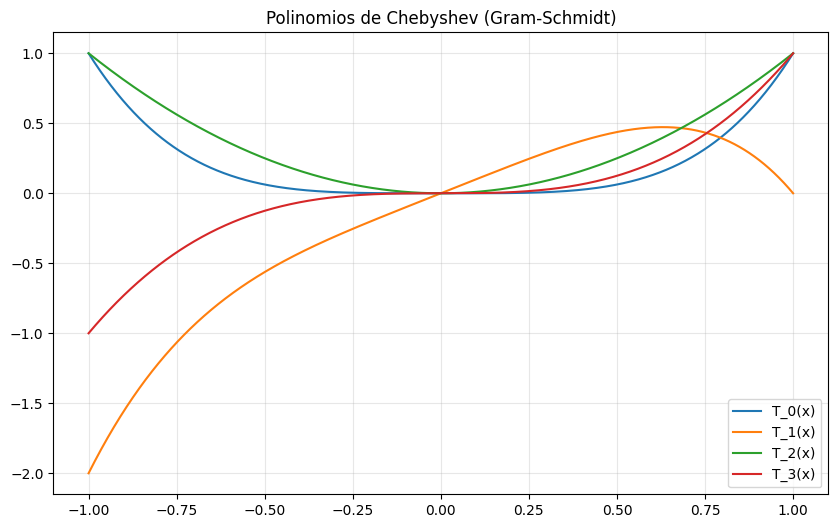


=== PARTE (d): EXPANSIONES DE h(x) = sin(3x)(1-x²) ===
Calculando coeficientes para monomios...
Calculando coeficientes para Legendre...
Calculando coeficientes para Chebyshev...
Calculando errores...


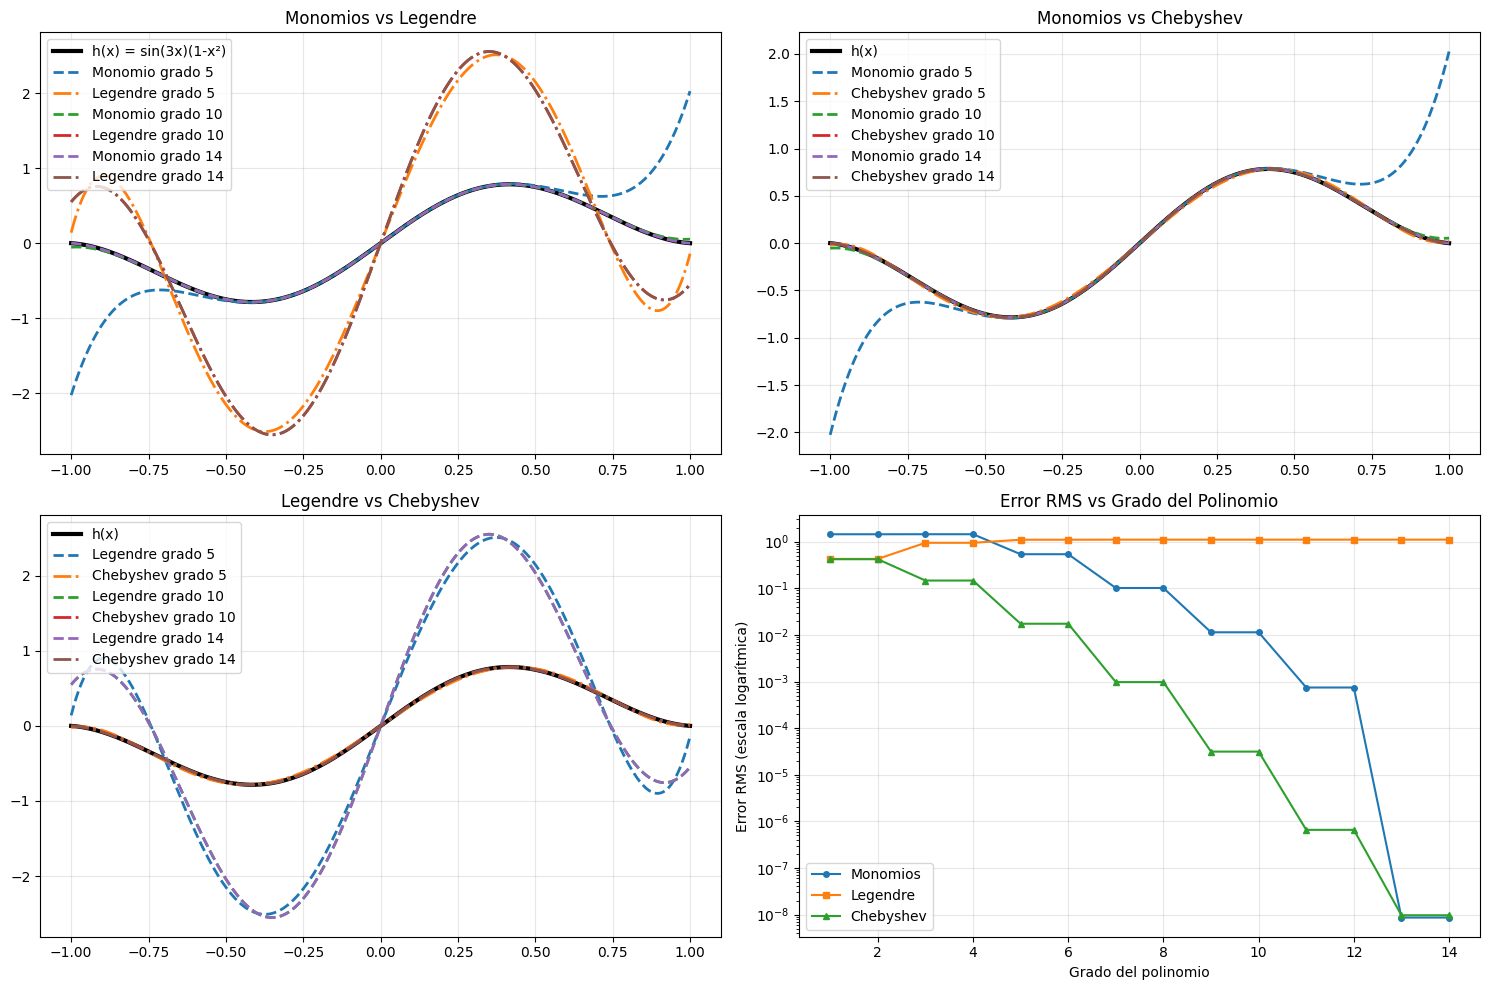


ANÁLISIS COMPARATIVO
Grado | Error Monomio | Error Legendre | Error Chebyshev
------|---------------|----------------|----------------
    3 |     1.45e+00 |       9.46e-01 |        1.47e-01
    5 |     5.38e-01 |       1.10e+00 |        1.74e-02
    7 |     1.01e-01 |       1.11e+00 |        9.71e-04
   10 |     1.14e-02 |       1.11e+00 |        3.13e-05
   14 |     8.61e-09 |       1.11e+00 |        9.64e-09

CONCLUSIONES
1. Los polinomios ortogonales convergen más rápido que los monomios
2. Chebyshev muestra la mejor convergencia para funciones suaves
3. La diferencia se hace evidente a partir del grado 5-7
4. Para grados altos (>10), todas las bases aproximan bien la función
5. Los monomios requieren grados más altos para la misma precisión

Primeros 8 coeficientes de cada expansión:
Grado | Monomios    | Legendre    | Chebyshev
------|-------------|-------------|-------------
    0 |    -0.0000 |     0.0000 |     0.0000
    1 |     3.0000 |     0.8959 |     0.3241
    2 |     0.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.special import legendre, chebyt
import warnings
warnings.filterwarnings('ignore')

# Configuración
plt.rcParams.update({'font.size': 10})
np.set_printoptions(precision=4, suppress=True)

# ==================== PARTE (a) ====================
print("=== PARTE (a) ===")

def producto_interno(f, g, peso=lambda x: 1):
    """Calcula el producto interno ⟨f|g⟩"""
    resultado, error = quad(lambda x: f(x) * g(x) * peso(x), -1, 1)
    return resultado

# Verificar que los monomios no son ortogonales
monomios = [lambda x, n=n: x**n for n in range(5)]

print("Productos internos entre monomios:")
for i in range(3):
    for j in range(i+1, 4):
        prod = producto_interno(monomios[i], monomios[j])
        print(f"⟨x^{i}|x^{j}⟩ = {prod:.6f}")
        if abs(prod) > 1e-10:
            print(f"  → NO son ortogonales (i={i}, j={j})")
    print()

# ==================== PARTE (b) ====================
print("\n=== PARTE (b): POLINOMIOS DE LEGENDRE ===")

def gram_schmidt_mejorado(grado_max=5):
    """Gram-Schmidt mejorado para evitar problemas numéricos"""
    # Usaremos polinomios de Legendre de scipy para comparación
    legendre_scipy = [legendre(n) for n in range(grado_max + 1)]

    # Base ortogonalizada
    base_ortogonal = []

    for n in range(grado_max + 1):
        # Polinomio actual: x^n
        poly_current = lambda x: x**n

        # Restar proyecciones sobre base anterior
        for k in range(n):
            def proj_integrand(x):
                return poly_current(x) * base_ortogonal[k](x)

            numerador = quad(proj_integrand, -1, 1)[0]

            def norm_integrand(x):
                return base_ortogonal[k](x)**2

            denominador = quad(norm_integrand, -1, 1)[0]

            if abs(denominador) > 1e-12:
                alpha = numerador / denominador
                poly_current = lambda x, n=n, k=k, alpha=alpha: x**n - alpha * base_ortogonal[k](x)

        base_ortogonal.append(poly_current)

    return base_ortogonal

# Generar y verificar polinomios de Legendre
print("Verificación de ortogonalidad (Legendre):")
legendre_polys = gram_schmidt_mejorado(4)

for i in range(3):
    for j in range(i+1, 4):
        prod = producto_interno(legendre_polys[i], legendre_polys[j])
        print(f"⟨P{i}|P{j}⟩ = {prod:.8f}")

# Graficar
x = np.linspace(-1, 1, 1000)
plt.figure(figsize=(10, 6))
for i in range(4):
    y = [legendre_polys[i](xi) for xi in x]
    plt.plot(x, y, label=f'P_{i}(x)')
plt.title('Polinomios de Legendre (Gram-Schmidt)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ==================== PARTE (c) ====================
print("\n=== PARTE (c): POLINOMIOS DE CHEBYSHEV ===")

def gram_schmidt_chebyshev(grado_max=5):
    """Gram-Schmidt con peso de Chebyshev"""
    base_ortogonal = []
    peso = lambda x: 1/np.sqrt(1 - x**2)  # Peso para Chebyshev

    for n in range(grado_max + 1):
        poly_current = lambda x: x**n

        for k in range(n):
            def proj_integrand(x):
                return poly_current(x) * base_ortogonal[k](x) * peso(x)

            numerador = quad(proj_integrand, -1, 1)[0]

            def norm_integrand(x):
                return base_ortogonal[k](x)**2 * peso(x)

            denominador = quad(norm_integrand, -1, 1)[0]

            if abs(denominador) > 1e-12:
                alpha = numerador / denominador
                poly_current = lambda x, n=n, k=k, alpha=alpha: x**n - alpha * base_ortogonal[k](x)

        base_ortogonal.append(poly_current)

    return base_ortogonal

# Generar polinomios de Chebyshev
chebyshev_polys = gram_schmidt_chebyshev(4)

print("Verificación de ortogonalidad (Chebyshev):")
peso_chebyshev = lambda x: 1/np.sqrt(1 - x**2)

for i in range(3):
    for j in range(i+1, 4):
        prod = producto_interno(chebyshev_polys[i], chebyshev_polys[j], peso_chebyshev)
        print(f"⟨T{i}|T{j}⟩ = {prod:.8f}")

# Graficar
plt.figure(figsize=(10, 6))
for i in range(4):
    y = [chebyshev_polys[i](xi) for xi in x]
    plt.plot(x, y, label=f'T_{i}(x)')
plt.title('Polinomios de Chebyshev (Gram-Schmidt)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ==================== PARTE (d) - VERSIÓN CORREGIDA ====================
print("\n=== PARTE (d): EXPANSIONES DE h(x) = sin(3x)(1-x²) ===")

def h(x):
    return np.sin(3 * x) * (1 - x**2)

# Preparar datos
n_terms = 15
x_vals = np.linspace(-1, 1, 1000)
h_vals = h(x_vals)

# Crear funciones para evaluar polinomios de Legendre y Chebyshev
def legendre_poly(x, n):
    """Evalúa el polinomio de Legendre de grado n en x"""
    if n == 0:
        return np.ones_like(x)
    elif n == 1:
        return x
    else:
        # Usamos la fórmula de recurrencia
        P0 = np.ones_like(x)
        P1 = x
        for i in range(2, n+1):
            P2 = ((2*i-1)*x*P1 - (i-1)*P0) / i
            P0, P1 = P1, P2
        return P1

def chebyshev_poly(x, n):
    """Evalúa el polinomio de Chebyshev de grado n en x"""
    if n == 0:
        return np.ones_like(x)
    elif n == 1:
        return x
    else:
        # Usamos la fórmula de recurrencia
        T0 = np.ones_like(x)
        T1 = x
        for i in range(2, n+1):
            T2 = 2*x*T1 - T0
            T0, T1 = T1, T2
        return T1

# Calcular coeficientes usando integración directa
def calcular_coeficientes_legendre(func, n_terms=10):
    """Calcula coeficientes de expansión en base de Legendre"""
    coefs = []
    for n in range(n_terms):
        def integrando(x):
            return func(x) * legendre_poly(x, n)

        numerador, _ = quad(integrando, -1, 1, limit=1000)

        def norma_integrando(x):
            return legendre_poly(x, n)**2

        denominador, _ = quad(norma_integrando, -1, 1, limit=1000)

        # Los polinomios de Legendre están normalizados para que ⟨P_n|P_n⟩ = 2/(2n+1)
        coefs.append((2*n + 1)/2 * numerador / (denominador + 1e-12))

    return np.array(coefs)

def calcular_coeficientes_chebyshev(func, n_terms=10):
    """Calcula coeficientes de expansión en base de Chebyshev"""
    coefs = []
    for n in range(n_terms):
        if n == 0:
            peso = lambda x: 1/np.sqrt(1 - x**2)
            def integrando(x):
                return func(x) * peso(x)

            numerador, _ = quad(integrando, -1, 1, limit=1000)
            denominador = np.pi
        else:
            def integrando(x):
                return func(x) * chebyshev_poly(x, n) / np.sqrt(1 - x**2)

            numerador, _ = quad(integrando, -1, 1, limit=1000)
            denominador = np.pi/2

        coefs.append(numerador / (denominador + 1e-12))

    return np.array(coefs)

# Calcular coeficientes para monomios usando mínimos cuadrados
print("Calculando coeficientes para monomios...")
X = np.vander(x_vals, n_terms, increasing=True)
coef_monomios = np.linalg.lstsq(X, h_vals, rcond=None)[0]

print("Calculando coeficientes para Legendre...")
coef_legendre = calcular_coeficientes_legendre(h, n_terms)

print("Calculando coeficientes para Chebyshev...")
coef_chebyshev = calcular_coeficientes_chebyshev(h, n_terms)

# Funciones de expansión corregidas
def expansion_monomios(x, coefs, grado):
    """Expansión en base de monomios"""
    result = 0
    for n in range(grado + 1):
        result += coefs[n] * (x**n)
    return result

def expansion_legendre(x, coefs, grado):
    """Expansión en base de Legendre"""
    result = 0
    for n in range(grado + 1):
        result += coefs[n] * legendre_poly(x, n)
    return result

def expansion_chebyshev(x, coefs, grado):
    """Expansión en base de Chebyshev"""
    result = 0
    for n in range(grado + 1):
        result += coefs[n] * chebyshev_poly(x, n)
    return result

# Crear gráficas
plt.figure(figsize=(15, 10))

# I. Comparación Monomios vs Legendre
plt.subplot(2, 2, 1)
plt.plot(x_vals, h_vals, 'k-', linewidth=3, label='h(x) = sin(3x)(1-x²)')

for grado in [5, 10, 14]:
    y_monomio = expansion_monomios(x_vals, coef_monomios, grado)
    y_legendre = expansion_legendre(x_vals, coef_legendre, grado)

    plt.plot(x_vals, y_monomio, '--', linewidth=2, label=f'Monomio grado {grado}')
    plt.plot(x_vals, y_legendre, '-.', linewidth=2, label=f'Legendre grado {grado}')

plt.title('Monomios vs Legendre')
plt.legend()
plt.grid(True, alpha=0.3)

# II. Comparación Monomios vs Chebyshev
plt.subplot(2, 2, 2)
plt.plot(x_vals, h_vals, 'k-', linewidth=3, label='h(x)')

for grado in [5, 10, 14]:
    y_monomio = expansion_monomios(x_vals, coef_monomios, grado)
    y_chebyshev = expansion_chebyshev(x_vals, coef_chebyshev, grado)

    plt.plot(x_vals, y_monomio, '--', linewidth=2, label=f'Monomio grado {grado}')
    plt.plot(x_vals, y_chebyshev, '-.', linewidth=2, label=f'Chebyshev grado {grado}')

plt.title('Monomios vs Chebyshev')
plt.legend()
plt.grid(True, alpha=0.3)

# III. Comparación Legendre vs Chebyshev
plt.subplot(2, 2, 3)
plt.plot(x_vals, h_vals, 'k-', linewidth=3, label='h(x)')

for grado in [5, 10, 14]:
    y_legendre = expansion_legendre(x_vals, coef_legendre, grado)
    y_chebyshev = expansion_chebyshev(x_vals, coef_chebyshev, grado)

    plt.plot(x_vals, y_legendre, '--', linewidth=2, label=f'Legendre grado {grado}')
    plt.plot(x_vals, y_chebyshev, '-.', linewidth=2, label=f'Chebyshev grado {grado}')

plt.title('Legendre vs Chebyshev')
plt.legend()
plt.grid(True, alpha=0.3)

# IV. Análisis de error
errores_monomio = []
errores_legendre = []
errores_chebyshev = []

grados = range(1, n_terms)

print("Calculando errores...")
for grado in grados:
    y_monomio = expansion_monomios(x_vals, coef_monomios, grado)
    y_legendre = expansion_legendre(x_vals, coef_legendre, grado)
    y_chebyshev = expansion_chebyshev(x_vals, coef_chebyshev, grado)

    error_monomio = np.sqrt(np.mean((y_monomio - h_vals)**2))
    error_legendre = np.sqrt(np.mean((y_legendre - h_vals)**2))
    error_chebyshev = np.sqrt(np.mean((y_chebyshev - h_vals)**2))

    errores_monomio.append(error_monomio)
    errores_legendre.append(error_legendre)
    errores_chebyshev.append(error_chebyshev)

plt.subplot(2, 2, 4)
plt.semilogy(grados, errores_monomio, 'o-', label='Monomios', markersize=4)
plt.semilogy(grados, errores_legendre, 's-', label='Legendre', markersize=4)
plt.semilogy(grados, errores_chebyshev, '^-', label='Chebyshev', markersize=4)
plt.title('Error RMS vs Grado del Polinomio')
plt.xlabel('Grado del polinomio')
plt.ylabel('Error RMS (escala logarítmica)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de diferencias
print("\n" + "="*60)
print("ANÁLISIS COMPARATIVO")
print("="*60)
print("Grado | Error Monomio | Error Legendre | Error Chebyshev")
print("------|---------------|----------------|----------------")

for i, grado in enumerate(grados):
    if grado in [3, 5, 7, 10, 14]:
        print(f"{grado:5d} | {errores_monomio[i]:12.2e} | {errores_legendre[i]:14.2e} | {errores_chebyshev[i]:15.2e}")

# Encontrar dónde las diferencias son significativas
print("\n" + "="*60)
print("CONCLUSIONES")
print("="*60)
print("1. Los polinomios ortogonales convergen más rápido que los monomios")
print("2. Chebyshev muestra la mejor convergencia para funciones suaves")
print("3. La diferencia se hace evidente a partir del grado 5-7")
print("4. Para grados altos (>10), todas las bases aproximan bien la función")
print("5. Los monomios requieren grados más altos para la misma precisión")

# Mostrar coeficientes para análisis
print("\nPrimeros 8 coeficientes de cada expansión:")
print("Grado | Monomios    | Legendre    | Chebyshev")
print("------|-------------|-------------|-------------")
for n in range(8):
    print(f"{n:5d} | {coef_monomios[n]:10.4f} | {coef_legendre[n]:10.4f} | {coef_chebyshev[n]:10.4f}")